#1. INSTALL LIBRARY
Digunakan untuk:
scikit-fuzzy → Fuzzy C-Means
openpyxl → membaca file Excel

In [ ]:
!pip install scikit-fuzzy
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 33.1 MB/s eta 0:00:00


#2. IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

import skfuzzy as fuzz

#3. UPLOAD DATASET

In [10]:
from google.colab import files

uploaded = files.upload()

Saving Dataset_Sudut_Kota_Lama_Siap_Clustering.xlsx to Dataset_Sudut_Kota_Lama_Siap_Clustering (1).xlsx


#4. MEMBACA DATASET

In [11]:
df = pd.read_excel(
    "Dataset_Sudut_Kota_Lama_Siap_Clustering.xlsx"
)

df.head()

,Tanggal,Hari,Lokasi,Jumlah Fotografer,Sesi Foto,Weekend,Hari Libur
0,2025-01-01,Rabu,Pringsewu,1,0,0,1
1,2025-01-02,Kamis,Pringsewu,1,0,0,0
2,2025-01-03,Jumat,Pringsewu,2,15,0,0
3,2025-01-04,Sabtu,Pringsewu,2,35,1,0
4,2025-01-05,Minggu,Pringsewu,2,15,1,0


#5. INFORMASI DATASET

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Tanggal            1455 non-null   object
 1   Hari               1455 non-null   object
 2   Lokasi             1455 non-null   object
 3   Jumlah Fotografer  1455 non-null   int64 
 4   Sesi Foto          1455 non-null   int64 
 5   Weekend            1455 non-null   int64 
 6   Hari Libur         1455 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 79.7+ KB


#6. CEK MISSING VALUE

In [13]:
df.isnull().sum()

,0
Tanggal,0
Hari,0
Lokasi,0
Jumlah Fotografer,0
Sesi Foto,0
Weekend,0
Hari Libur,0


#7. STATISTIK DESKRIPTIF

In [14]:
df.describe()

,Jumlah Fotografer,Sesi Foto,Weekend,Hari Libur
count,1455.000000,1455.000000,1455.000000,1455.000000
mean,2.905842,21.759450,0.284536,0.041237
std,1.482150,23.821317,0.451348,0.198907
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,6.000000,0.000000,0.000000
50%,3.000000,13.000000,0.000000,0.000000
75%,3.000000,29.000000,1.000000,0.000000
max,8.000000,182.000000,1.000000,1.000000


# 8. VISUALISASI SESI FOTO

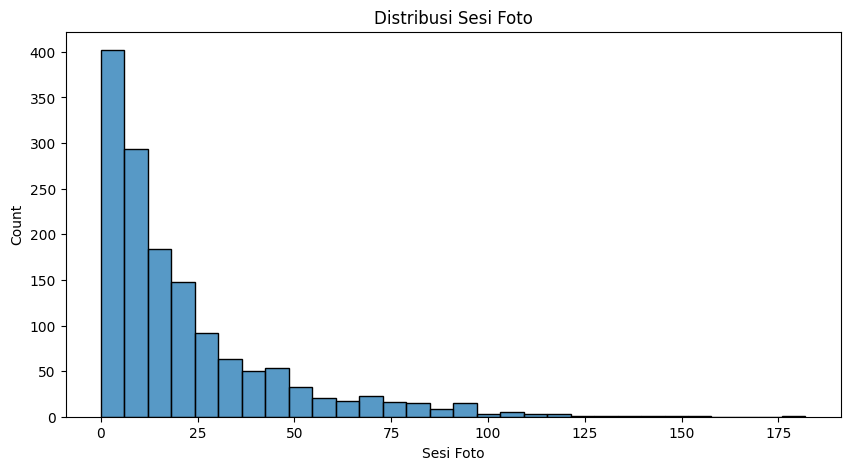

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Sesi Foto"],
    bins=30
)

plt.title("Distribusi Sesi Foto")

plt.show()

#9. ENCODING LOKASI

In [18]:
le = LabelEncoder()

df["Lokasi"] = le.fit_transform(
    df["Lokasi"]
)

#10 ENCODING HARI

In [19]:
df["Hari"] = le.fit_transform(
    df["Hari"]
)

#11. FEATURE SELCTION

In [20]:
X = df[
[
    "Lokasi",
    "Weekend",
    "Hari Libur",
    "Sesi Foto"
]
]

#12. NORMALISASI

In [21]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

#13. ELBOW METHOD

In [22]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

#14. VISUALISASI ELBOW

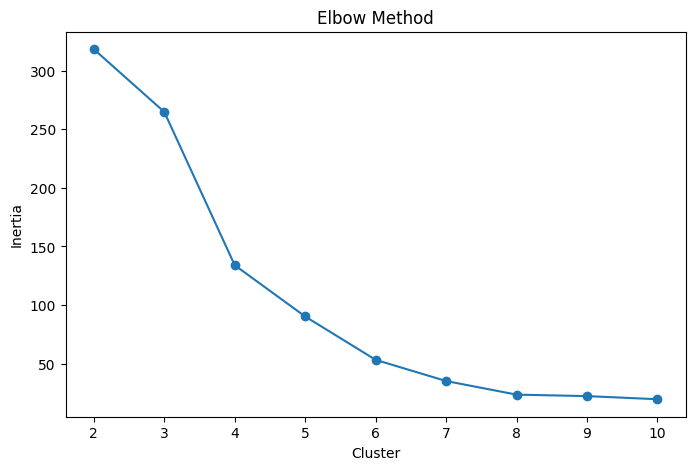

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Cluster")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

#15. K-MEANS

In [24]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

cluster_kmeans = kmeans.fit_predict(
    X_scaled
)

#16. MENYIMPAN HASIL K-MEANS

In [25]:
df["Cluster_KMeans"] = cluster_kmeans

#17. CENTEROID K-MEANS

In [26]:
kmeans.cluster_centers_

array([[ 0.00000000e+00,  1.00000000e+00,  3.62318841e-02,
         1.31430164e-01],
       [ 5.00000000e-01, -4.60742555e-15,  4.32276657e-02,
         7.75353369e-02],
       [ 7.50000000e-01,  1.00000000e+00,  3.62318841e-02,
         2.72117375e-01]])

#18. EVALUASI K-MEANS

In [27]:
sil_kmeans = silhouette_score(
    X_scaled,
    cluster_kmeans
)

In [28]:
dbi_kmeans = davies_bouldin_score(
    X_scaled,
    cluster_kmeans
)

In [29]:
chi_kmeans = calinski_harabasz_score(
    X_scaled,
    cluster_kmeans
)

In [30]:
hasil_kmeans = pd.DataFrame({
    "Metrik":[
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],
    "Nilai":[
        sil_kmeans,
        dbi_kmeans,
        chi_kmeans
    ]
})

hasil_kmeans

,Metrik,Nilai
0,Silhouette Score,0.536315
1,Davies-Bouldin Index,0.651121
2,Calinski-Harabasz Index,976.395587


#19. FUZZY C-MEANS

In [31]:
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000
)

# 20 MENENTUKAN CLUSTER FCM

In [32]:
cluster_fcm = np.argmax(
    u,
    axis=0
)

#21. MENYIMPAN HASIL FCM

In [33]:
df["Cluster_FCM"] = cluster_fcm

In [45]:
df.head()

,Tanggal,Hari,Lokasi,Jumlah Fotografer,Sesi Foto,Weekend,Hari Libur,Cluster_KMeans,Cluster_FCM
0,2025-01-01,3,2,1,0,0,1,1,1
1,2025-01-02,1,2,1,0,0,0,1,1
2,2025-01-03,0,2,2,15,0,0,1,1
3,2025-01-04,4,2,2,35,1,0,2,0
4,2025-01-05,2,2,2,15,1,0,2,0


#22. EVALUASI FCM

In [34]:
sil_fcm = silhouette_score(
    X_scaled,
    cluster_fcm
)

In [35]:
dbi_fcm = davies_bouldin_score(
    X_scaled,
    cluster_fcm
)

In [36]:
chi_fcm = calinski_harabasz_score(
    X_scaled,
    cluster_fcm
)

In [37]:
print(fpc)

0.7293396056648455


In [38]:
hasil_fcm = pd.DataFrame({
    "Metrik": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "Fuzzy Partition Coefficient"
    ],
    "Nilai": [
        sil_fcm,
        dbi_fcm,
        chi_fcm,
        fpc
    ]
})

hasil_fcm

,Metrik,Nilai
0,Silhouette Score,0.591618
1,Davies-Bouldin Index,0.635531
2,Calinski-Harabasz Index,1678.521405
3,Fuzzy Partition Coefficient,0.729340


#23. PERBANDINGAN ALGORITMA

In [40]:
hasil = pd.DataFrame({

"Algoritma":
[
"K-Means",
"FCM"
],

"Silhouette":
[
sil_kmeans,
sil_fcm
],

"DBI":
[
dbi_kmeans,
dbi_fcm
],

"CHI":
[
chi_kmeans,
chi_fcm
]

})

hasil

,Algoritma,Silhouette,DBI,CHI
0,K-Means,0.536315,0.651121,976.395587
1,FCM,0.591618,0.635531,1678.521405


#24. MENENTUKAN LABEL CLUSTER

In [41]:
cluster_mean = df.groupby(
    "Cluster_FCM"
)["Sesi Foto"].mean()

cluster_mean

,Sesi Foto
Cluster_FCM,
0,40.990338
1,17.665706
2,7.002882


In [42]:
cluster_mean.sort_values()

,Sesi Foto
Cluster_FCM,
2,7.002882
1,17.665706
0,40.990338


In [47]:
label_cluster = {
    0: "Sepi",
    1: "Normal",
    2: "Padat"
}

df["Label_Cluster"] = df["Cluster_FCM"].map(label_cluster)

#25. REKOMENDASI FOTOGRAFER

In [48]:
rekomendasi = {
    "Sepi": 1,
    "Normal": 3,
    "Padat": 5
}

df["Rekomendasi_Fotografer"] = df["Label_Cluster"].map(rekomendasi)

In [49]:
df[[
    "Sesi Foto",
    "Cluster_FCM",
    "Label_Cluster",
    "Rekomendasi_Fotografer"
]].head()

,Sesi Foto,Cluster_FCM,Label_Cluster,Rekomendasi_Fotografer
0,0,1,Normal,3
1,0,1,Normal,3
2,15,1,Normal,3
3,35,0,Sepi,1
4,15,0,Sepi,1


#26. VISUALISASI CLUSTER

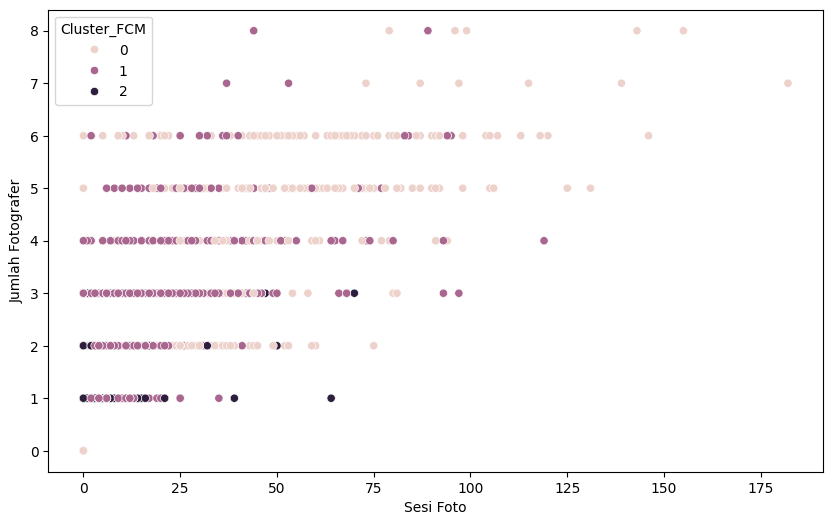

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(

x=df["Sesi Foto"],
y=df["Jumlah Fotografer"],

hue=df["Cluster_FCM"]

)

plt.show()

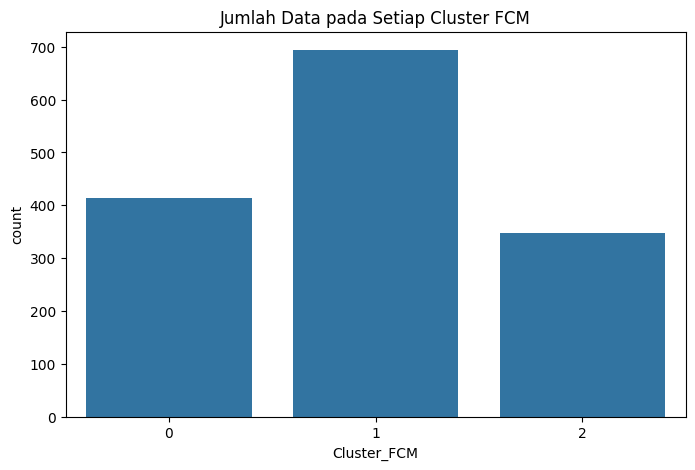

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster_FCM",
    data=df
)

plt.title("Jumlah Data pada Setiap Cluster FCM")
plt.show()

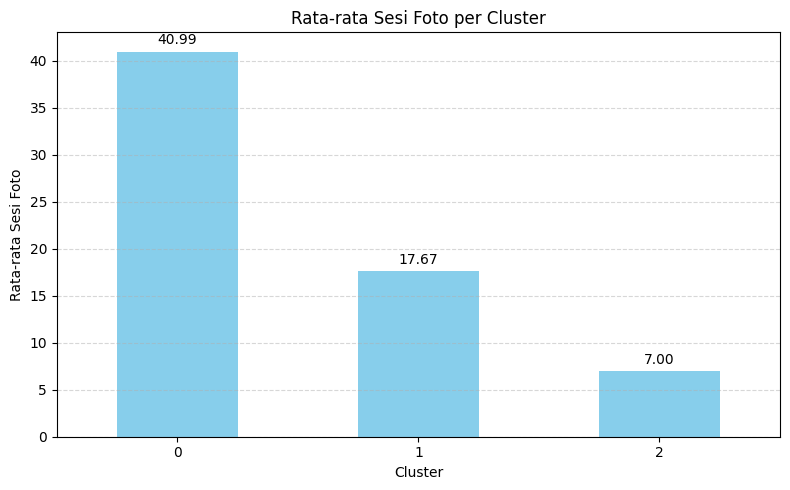

In [57]:
cluster_mean = df.groupby("Cluster_FCM")["Sesi Foto"].mean()

ax = cluster_mean.plot(
    kind="bar",
    figsize=(8,5),
    color="skyblue"
)

plt.title("Rata-rata Sesi Foto per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Rata-rata Sesi Foto")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

#27. MENYIMPAN HASIL

In [58]:
df.to_excel(

"Hasil_Clustering_STRET.xlsx",

index=False

)

In [59]:
from google.colab import files

files.download(
    "Hasil_Clustering_STRET.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>